In [ ]:
import pandas as pd
import numpy as np
import gdown

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [ ]:
# ID del archivo en Google Drive
file_id = "1A8_Lt74vXHWC-iqk4lIzcOMYNsEi_haD"  #ID del archivo ubicado en Drive
url = f"https://drive.google.com/uc?id={file_id}" #Ruta para utilizar Drive

# Descargar archivo al entorno de ejecución
gdown.download(url, "muestra_dataset_10%.csv", quiet=False)

# Leer el archivo en pandas
dfl = pd.read_csv("muestra_dataset_10%.csv")

dflx = dfl.copy() #Copia al dataframe original
#siempre es recomendable gtrabajar con una copia

dflx.head() #muestra las primeras filas del dataframe, si no se coloca un parametro muestra las primeras 5 por defecto

#dflx.tail() #muestra las ultimas filas del dataframe, si no se coloca un parametro muestra las ultimas 5 por defecto

#dflx.sample(20) #seleciona 20 ejemplos del dataframe para visualizar

Downloading...
From (original): https://drive.google.com/uc?id=1A8_Lt74vXHWC-iqk4lIzcOMYNsEi_haD
From (redirected): https://drive.google.com/uc?id=1A8_Lt74vXHWC-iqk4lIzcOMYNsEi_haD&confirm=t&uuid=27cd4615-4a20-43e4-898d-d3c3027d2e6d
To: /content/muestra_dataset_10%.csv
100%|██████████| 141M/141M [00:02<00:00, 50.0MB/s]


,Ds,Fecha,Hora,Tem_BME280,Hum_BME280,Pres_BME280,Alt_BME280,MP1.0_StP,MP2.5_StP,MP10_StP,...,MP_gt_2.5um,MP_gt_5.0um,MP_gt_10um,CO2_MHZ19,Dir_Viento,Rap_Viento,Agua_Caida,CONSUMO_1,CONSUMO_2,CONSUMO_3
0,Ju,07-12-23,19:29:16,26.2,34.3,990.4,191.6,1.0,1.0,1.0,...,0.0,0.0,0.0,400.0,270.0,0.0,0.0,0.0,0.0,0.0
1,Lu,29-07-24,11:05:16,17.4,38.0,957.3,476.4,53.0,75.0,83.0,...,27.0,10.0,2.0,590.2,270.0,0.0,0.0,0.0,0.0,0.0
2,Mi,22-03-23,07:41:27,15.3,51.2,981.0,272.0,6.0,8.0,8.0,...,3.0,0.0,0.0,591.6,270.0,0.0,0.0,0.0,0.0,0.0
3,Lu,15-05-23,14:55:31,18.8,55.8,1003.6,80.9,4.0,5.0,6.0,...,4.0,1.0,0.0,440.7,270.0,0.0,0.0,13.7,0.0,0.0
4,Lu,12-02-24,16:48:55,33.1,26.2,996.9,137.1,286.0,287.0,287.0,...,0.0,0.0,0.0,403.0,270.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
dflx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960228 entries, 0 to 960227
Data columns (total 26 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Ds           960228 non-null  object 
 1   Fecha        960228 non-null  object 
 2   Hora         960228 non-null  object 
 3   Tem_BME280   960228 non-null  float64
 4   Hum_BME280   960228 non-null  float64
 5   Pres_BME280  960228 non-null  float64
 6   Alt_BME280   960228 non-null  float64
 7   MP1.0_StP    960228 non-null  float64
 8   MP2.5_StP    960228 non-null  float64
 9   MP10_StP     960228 non-null  float64
 10  MP1.0_AtE    960228 non-null  float64
 11  MP2.5_AtE    960228 non-null  float64
 12  MP10_AtE     960228 non-null  float64
 13  MP_gt_0.3um  960228 non-null  float64
 14  MP_gt_0.5um  960228 non-null  float64
 15  MP_gt_1.0um  960228 non-null  float64
 16  MP_gt_2.5um  960228 non-null  float64
 17  MP_gt_5.0um  960228 non-null  float64
 18  MP_gt_10um   960228 non-

In [ ]:
# Verificar si hay valores nulos en la columna "Fecha"
nulos_fecha = dflx["Fecha"].isnull().sum()
print("Cantidad de valores nulos en 'Fecha':", nulos_fecha)

# Ver los valores únicos de la columna "Fecha"
valores_unicos = dflx["Fecha"].unique()
print("Valores únicos en 'Fecha':", valores_unicos)

# Opcional: cuántos valores únicos tiene
print("Cantidad de valores únicos en 'Fecha':", dflx["Fecha"].nunique())

Cantidad de valores nulos en 'Fecha': 0
Valores únicos en 'Fecha': ['07-12-23' '29-07-24' '22-03-23' '15-05-23' '12-02-24' '19-01-23'
 '27-08-23' '20-01-23' '23-03-23' '15-04-23' '29-07-23' '29-06-23'
 '21-09-23' '25-07-23' '08-04-23' '03-04-23' '23-09-23' '26-03-25'
 '26-01-23' '23-10-23' '11-03-23' '25-08-23' '07-03-23' '04-09-23'
 '28-04-23' '29-05-23' '19-06-23' '16-02-23' '01-06-24' '03-07-23'
 '13-05-23' '03-02-24' '19-06-24' '04-07-23' '08-06-23' '05-01-23'
 '26-05-23' '12-05-25' '27-12-24' '27-03-25' '10-10-23' '13-09-23'
 '30-08-23' '01-03-24' '06-06-24' '01-08-24' '14-04-25' '01-10-23'
 '02-11-24' '04-05-23' '17-08-23' '22-05-23' '11-05-24' '16-08-23'
 '21-10-23' '30-05-23' '26-11-23' '14-05-23' '29-01-23' '31-12-22'
 '16-12-23' '19-11-23' '02-01-23' '18-04-25' '30-03-23' '05-03-23'
 '01-01-23' '09-06-23' '07-04-23' '14-01-23' '24-04-23' '13-10-23'
 '16-09-23' '17-04-23' '31-08-23' '01-11-23' '30-07-23' '03-08-23'
 '01-03-23' '17-05-23' '24-06-23' '17-01-23' '24-01-23' '13-02

In [ ]:
# Fechas atípicas que quieres revisar
fechas_erroneas = ["DD-MM-AA", "00-00-ff", "00-00-00"]

# Contar cuántos registros hay de cada una
conteo_erroneas = dflx["Fecha"].value_counts().loc[lambda x: x.index.isin(fechas_erroneas)]
print(conteo_erroneas)

# Total de registros erróneos
total_erroneos = dflx["Fecha"].isin(fechas_erroneas).sum()
print("Total de registros con fechas erróneas:", total_erroneos)

Fecha
DD-MM-AA    28
00-00-ff     1
Name: count, dtype: int64
Total de registros con fechas erróneas: 29


In [ ]:
# Lista de fechas inválidas
fechas_erroneas = ["DD-MM-AA", "00-00-ff", "00-00-00"]

# Eliminar esas filas
dflx = dflx[~dflx["Fecha"].isin(fechas_erroneas)].copy()

print("Nuevo tamaño del dataset:", dflx.shape)

Nuevo tamaño del dataset: (960199, 26)


In [ ]:
# Verificar si hay valores nulos en la columna "Ds"
nulos_Ds = dflx["Ds"].isnull().sum()
print("Cantidad de valores nulos en 'Ds':", nulos_Ds)

# Ver los valores únicos de la columna "Ds"
valores_unicos = dflx["Ds"].unique()
print("Valores únicos en 'Ds':", valores_unicos)

# Opcional: cuántos valores únicos tiene
print("Cantidad de valores únicos en 'Ds':", dflx["Ds"].nunique())

Cantidad de valores nulos en 'Ds': 0
Valores únicos en 'Ds': ['Ju' 'Lu' 'Mi' 'Do' 'Vi' 'Sa' 'Ma']
Cantidad de valores únicos en 'Ds': 7


In [ ]:
# Definir el mapeo manual
orden_dias = {'Lu': 0, 'Ma': 1, 'Mi': 2, 'Ju': 3, 'Vi': 4, 'Sa': 5, 'Do': 6}

# Aplicar el mapeo directamente sobre la columna 'Ds'
dflx['Ds'] = dflx['Ds'].map(orden_dias)

# Verificar si hubo algún valor no mapeado
valores_no_mapeados = dflx[dflx['Ds'].isna()]
if not valores_no_mapeados.empty:
    print("⚠️ Valores no mapeados encontrados:")
    print(valores_no_mapeados['Ds'].unique())
else:
    print("✅ La columna 'Ds' fue transformada correctamente.")

# Mostrar las primeras filas para confirmar
print(dflx.head())

✅ La columna 'Ds' fue transformada correctamente.
   Ds     Fecha      Hora  Tem_BME280  Hum_BME280  Pres_BME280  Alt_BME280  \
0   3  07-12-23  19:29:16        26.2        34.3        990.4       191.6   
1   0  29-07-24  11:05:16        17.4        38.0        957.3       476.4   
2   2  22-03-23  07:41:27        15.3        51.2        981.0       272.0   
3   0  15-05-23  14:55:31        18.8        55.8       1003.6        80.9   
4   0  12-02-24  16:48:55        33.1        26.2        996.9       137.1   

   MP1.0_StP  MP2.5_StP  MP10_StP  ...  MP_gt_2.5um  MP_gt_5.0um  MP_gt_10um  \
0        1.0        1.0       1.0  ...          0.0          0.0         0.0   
1       53.0       75.0      83.0  ...         27.0         10.0         2.0   
2        6.0        8.0       8.0  ...          3.0          0.0         0.0   
3        4.0        5.0       6.0  ...          4.0          1.0         0.0   
4      286.0      287.0     287.0  ...          0.0          0.0         0.0   



In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1️⃣ Crear una copia del dataframe original
dflx_escaled = dflx.copy()

# 2️⃣ Eliminar las variables categóricas especificadas
cols_to_drop = ['Fecha', 'Hora']
dflx_escaled = dflx_escaled.drop(columns=cols_to_drop, errors='ignore')

# 3️⃣ Aplicar MinMaxScaler a las variables numéricas
scaler = MinMaxScaler()
dflx_escaled_scaled_values = scaler.fit_transform(dflx_escaled)

# 4️⃣ Reconstruir el DataFrame escalado manteniendo los nombres de columnas
dflx_escaled = pd.DataFrame(dflx_escaled_scaled_values, columns=dflx_escaled.columns)

# 5️⃣ Confirmar que todo se realizó correctamente
print("✅ Dataset normalizado correctamente (rango 0 a 1).")
print("Variables normalizadas:", dflx_escaled.columns.tolist())
print("\nVista previa:")
print(dflx_escaled.head())

✅ Dataset normalizado correctamente (rango 0 a 1).
Variables normalizadas: ['Ds', 'Tem_BME280', 'Hum_BME280', 'Pres_BME280', 'Alt_BME280', 'MP1.0_StP', 'MP2.5_StP', 'MP10_StP', 'MP1.0_AtE', 'MP2.5_AtE', 'MP10_AtE', 'MP_gt_0.3um', 'MP_gt_0.5um', 'MP_gt_1.0um', 'MP_gt_2.5um', 'MP_gt_5.0um', 'MP_gt_10um', 'CO2_MHZ19', 'Dir_Viento', 'Rap_Viento', 'Agua_Caida', 'CONSUMO_1', 'CONSUMO_2', 'CONSUMO_3']

Vista previa:
         Ds  Tem_BME280  Hum_BME280  Pres_BME280  Alt_BME280  MP1.0_StP  \
0  0.500000    0.658810    0.303287     0.568744    0.228122      0.002   
1  0.000000    0.560045    0.342524     0.241345    0.567210      0.106   
2  0.333333    0.536476    0.482503     0.475767    0.323848      0.012   
3  0.000000    0.575758    0.531283     0.699308    0.096321      0.008   
4  0.000000    0.736251    0.217391     0.633037    0.163234      0.572   

   MP2.5_StP  MP10_StP  MP1.0_AtE  MP2.5_AtE  ...  MP_gt_2.5um  MP_gt_5.0um  \
0      0.002  0.001667      0.002      0.002  ...       0

In [ ]:
def metodo_codo_kmean(valores):  # Define una función que aplica el método del codo para KMeans usando los datos dados
    X = valores  # Asigna los datos de entrada a la variable X

    wcss = []  # Inicializa una lista vacía para guardar los valores de inercia (WCSS) para cada número de clusters

    for i in range(1, 11):  # Itera desde 1 hasta 10 clusters
        km = KMeans(
            n_clusters=i,         # Establece el número de clusters en i
            init='k-means++',     # Usa el método 'k-means++' para inicializar los centroides eficientemente
            max_iter=300,         # Define el número máximo de iteraciones por ejecución
            n_init=10,            # Realiza 10 inicializaciones con diferentes centroides aleatorios y elige la mejor
            random_state=11       # Fija la semilla aleatoria para reproducibilidad
        )
        km.fit(X)  # Ajusta el modelo KMeans a los datos X
        wcss.append(km.inertia_)  # Guarda la inercia (suma de distancias cuadradas dentro de los clusters)

    plt.plot(range(1, 11), wcss)  # Grafica los valores de inercia para cada número de clusters
    plt.title('Método del codo')  # Título del gráfico
    plt.xlabel('Número de clusters')  # Etiqueta del eje X
    plt.ylabel('Inercia')  # Etiqueta del eje Y
    plt.show()  # Muestra la gráfica

In [ ]:
print(dflx.columns.tolist())

['Ds', 'Fecha', 'Hora', 'Tem_BME280', 'Hum_BME280', 'Pres_BME280', 'Alt_BME280', 'MP1.0_StP', 'MP2.5_StP', 'MP10_StP', 'MP1.0_AtE', 'MP2.5_AtE', 'MP10_AtE', 'MP_gt_0.3um', 'MP_gt_0.5um', 'MP_gt_1.0um', 'MP_gt_2.5um', 'MP_gt_5.0um', 'MP_gt_10um', 'CO2_MHZ19', 'Dir_Viento', 'Rap_Viento', 'Agua_Caida', 'CONSUMO_1', 'CONSUMO_2', 'CONSUMO_3']


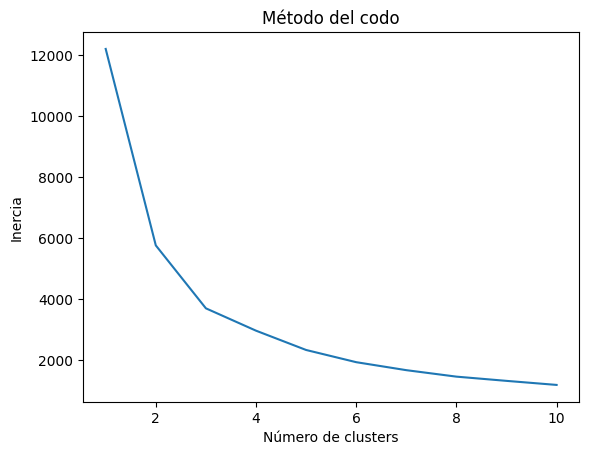

In [ ]:
# Llama a la función 'metodo_codo_kmean' usando los valores seleccionados para aplicar el método del codo
valores = dflx_escaled[["Tem_BME280","MP1.0_AtE"]].values  # Extrae las columnas 'VelRafaga' y 'Temp9am' del DataFrame como un array NumPy
metodo_codo_kmean(valores)

In [ ]:
import pickle
from sklearn.cluster import KMeans

def run_kmeans(X, k, model_filename="modelo_kmeans.pkl"):  # Define una función para ejecutar KMeans con k clusters y visualizar los resultados
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)  # Inicializa el modelo KMeans con los parámetros especificados
    y_means = km.fit_predict(X)  # Ajusta el modelo a los datos X y devuelve las etiquetas de los clusters para cada punto

    # Guardar el modelo entrenado con pickle
    with open(model_filename, 'wb') as file:
        pickle.dump(km, file)
    print(f"✅ Modelo KMeans guardado correctamente en '{model_filename}'")

    # Visualizar clusters para k=5
    colors = ['orange', 'limegreen', 'deepskyblue', 'indianred', 'gold']  # Define una lista de colores para diferenciar los clusters

    # Crear un gráfico para cada cluster
    for i in range(k):  # Itera sobre cada cluster
        plt.scatter(  # Dibuja los puntos que pertenecen al cluster i
            X[y_means==i, 0],  # Coordenadas X de los puntos del cluster i
            X[y_means==i, 1],  # Coordenadas Y de los puntos del cluster i
            s=100,             # Tamaño de los puntos
            c=colors[i],       # Color asignado al cluster
            label=f'Cluster {i}',  # Etiqueta del cluster
            linewidths=1, edgecolors='black'  # Borde negro para los puntos
        )

    # Graficar los centroides
    plt.scatter(
        km.cluster_centers_[:, 0],  # Coordenada X de los centroides
        km.cluster_centers_[:, 1],  # Coordenada Y de los centroides
        s=200, marker='*', c='red', alpha=0.7,  # Tamaño, forma y color de los centroides
        label='Centroides', linewidths=1, edgecolors='darkred'  # Etiqueta y borde de los centroides
    )

    # Título y etiquetas
    plt.title('Clusters with KMeans (3)')  # Título del gráfico
    plt.xlabel('MP1.0_AtE')  # Etiqueta del eje X
    plt.ylabel('Tem_BME280')  # Etiqueta del eje Y
    plt.legend()  # Muestra la leyenda del gráfico
    plt.show()  # Muestra la gráfica

    return y_means  # Devuelve las etiquetas asignadas a cada punto por el modelo KMeans

✅ Modelo KMeans guardado correctamente en 'modelo_kmeans.pkl'


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


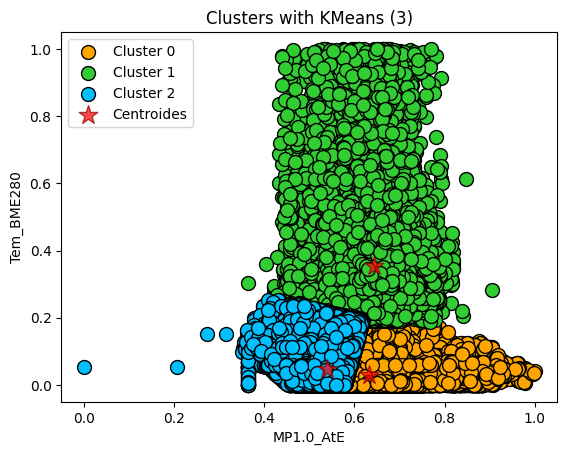

In [ ]:
# Ejecuta KMeans con 5 clusters sobre los valores seleccionados y guarda las etiquetas de cluster en 'y_means'
y_means = run_kmeans(valores, 3)

In [ ]:
import json
import pickle
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# === CONFIGURA SEGÚN TU CASO ===
MODEL_PATH = "/content/modelo_kmeans.pkl"     # el archivo que ya generaste
CSV_PATH = "/content/muestra_dataset_10%.csv"            # tu dataset original (para ajustar el scaler)
FEATURES = ["Tem_BME280", "MP1.0_AtE"]        # mismas columnas que usaste en el entrenamiento
TRAINED_ON = "minmax"                         # "minmax" si entrenaste sobre datos escalados, "original" si no

# === 1. Cargar modelo entrenado ===
with open(MODEL_PATH, "rb") as f:
    km = pickle.load(f)
print("✅ Modelo cargado:", MODEL_PATH)

# === 2. Cargar dataset para reconstruir MinMaxScaler ===
import pandas as pd
df = pd.read_csv(CSV_PATH)
X = df[FEATURES].astype(float).values
scaler = MinMaxScaler().fit(X)
print("Scaler ajustado con el dataset.")

# === 3. Determinar centroides escalados y originales ===
cent = np.array(km.cluster_centers_, dtype=float)

if TRAINED_ON.lower() == "minmax":
    cent_scaled = cent.copy()
    cent_original = scaler.inverse_transform(cent_scaled)
elif TRAINED_ON.lower() == "original":
    cent_original = cent.copy()
    cent_scaled = scaler.transform(cent_original)
else:
    raise ValueError("TRAINED_ON debe ser 'minmax' o 'original'.")

# === 4. Guardar los JSON en /content ===
# Centroides escalados
centroides_scaled = [
    {"cluster": int(i), "values": [float(v) for v in row]}
    for i, row in enumerate(cent_scaled)
]
with open("centroides_scaled.json", "w", encoding="utf-8") as f:
    json.dump(centroides_scaled, f, indent=2)
print("📁 centroides_scaled.json creado")

# Centroides originales
centroides_original = [
    {"cluster": int(i), FEATURES[0]: float(r[0]), FEATURES[1]: float(r[1])}
    for i, r in enumerate(cent_original)
]
with open("centroides_original.json", "w", encoding="utf-8") as f:
    json.dump(centroides_original, f, indent=2)
print("📁 centroides_original.json creado")

# Parámetros del scaler
scaler_json = {
    "feature_order": FEATURES,
    "data_min_": scaler.data_min_.tolist(),
    "data_max_": scaler.data_max_.tolist(),
}
with open("scaler_minmax.json", "w", encoding="utf-8") as f:
    json.dump(scaler_json, f, indent=2)
print("⚙️ scaler_minmax.json creado")

print("\n✅ Exportación completada.")


✅ Modelo cargado: /content/modelo_kmeans.pkl
Scaler ajustado con el dataset.
📁 centroides_scaled.json creado
📁 centroides_original.json creado
⚙️ scaler_minmax.json creado

✅ Exportación completada.
